In [16]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle
import os


from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

import statsmodels.api as sm
import pmdarima as pm


In [4]:
with open("/glade/work/stevenxu/FAIR_models/origional_model.pkl", "rb") as f_in:
    f1 = pickle.load(f_in)

with open("/glade/work/stevenxu/FAIR_models/top12_model.pkl", "rb") as f_in:
    f2 = pickle.load(f_in)

with open("/glade/work/stevenxu/FAIR_models/top20_model.pkl", "rb") as f_in:
    f3 = pickle.load(f_in)

with open("/glade/work/stevenxu/FAIR_models/arima_list.pkl", "rb") as f:
    arima_list = pickle.load(f)

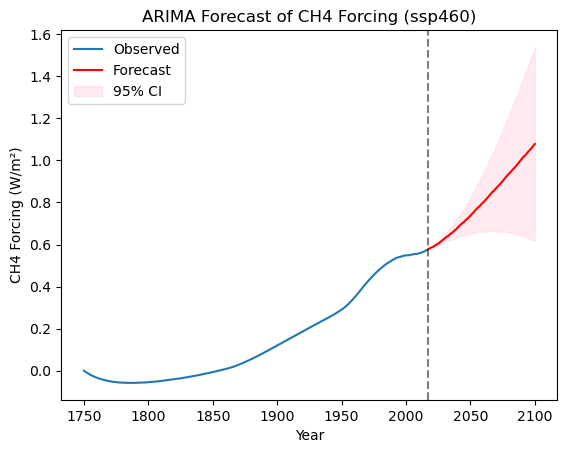

In [13]:
startyear = 2017
endyear = 2100
specie = 'CH4'
model = arima_list[specie]

da = f1.forcing.sel(specie=specie, scenario = f1.scenarios[5], timebounds = slice(None, startyear)).mean(dim="config")
ffl_fc, ffl_conf_int = model.predict(n_periods=endyear-startyear, return_conf_int=True)

# historical data
pl.plot(da["timebounds"].values, da.values, label="Observed")

# forecast horizon (years after yrfcm = 2017)
future_years = np.arange(startyear + 1, endyear + 1)

# forecast mean
pl.plot(future_years, ffl_fc, label="Forecast", color="red")

# confidence interval
pl.fill_between(
    future_years,
    ffl_conf_int[:, 0],
    ffl_conf_int[:, 1],
    color="pink",
    alpha=0.3,
    label="95% CI"
)

pl.axvline(startyear, color="k", linestyle="--", alpha=0.5)
pl.xlabel("Year")
pl.ylabel("CH4 Forcing (W/m²)")
pl.title(f"ARIMA Forecast of {specie} Forcing ({da.scenario.values})")
pl.legend()
pl.show()


In [17]:
save_dir = "/glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots"
startyear, endyear = 2017, 2100

for specie, model in arima_list.items():
    print(f"Processing {specie}...")

    # Historical data (use the same scenario index as in training)
    da = f1.forcing.sel(specie=specie, scenario=f1.scenarios[5], timebounds=slice(None, startyear)).mean(dim="config")

    # Forecast
    n_steps = endyear - startyear
    fc, ci = model.predict(n_periods=n_steps, return_conf_int=True)
    future_years = np.arange(startyear + 1, endyear + 1)

    # Plot
    pl.figure(figsize=(7, 5))
    pl.plot(da["timebounds"].values, da.values, label="Observed")
    pl.plot(future_years, fc, label="Forecast", color="red")
    pl.fill_between(future_years, ci[:, 0], ci[:, 1], alpha=0.3, color="pink", label="95% CI")
    pl.axvline(startyear, color="k", linestyle="--", alpha=0.5)
    pl.xlabel("Year")
    pl.ylabel(f"{specie} Forcing (W/m²)")
    pl.title(f"ARIMA Forecast of {specie} Forcing ({da.scenario.values})")
    pl.legend()

    # Save figure
    save_path = os.path.join(save_dir, f"{specie}_arima_forecast.png")
    pl.savefig(save_path, dpi=300, bbox_inches="tight")
    pl.close()

    print(f"Saved: {save_path}")

Processing CO2...
Saved: /glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/CO2_arima_forecast.png
Processing CH4...
Saved: /glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/CH4_arima_forecast.png
Processing N2O...
Saved: /glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/N2O_arima_forecast.png
Processing CFC-11...
Saved: /glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/CFC-11_arima_forecast.png
Processing CFC-12...
Saved: /glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/CFC-12_arima_forecast.png
Processing CFC-113...
Saved: /glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/CFC-113_arima_forecast.png
Processing CFC-114...
Saved: /glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/CFC-114_arima_forecast.png
Processing CFC-115...
Saved: /glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/CFC-115_arima_forecast.png
Processing HCFC-22...
Saved: /glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/HC